# Energy Simulation with PyBaMM

This notebook demonstrates how to perform energy/capacity simulation using PyBaMM with BYD Blade Prismatic 135Ah cell parameters.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Chemistry**: LFP (Lithium Iron Phosphate)
- **Form Factor**: Prismatic
- **Nominal Voltage**: 3.3V
- **Capacity**: 135Ah
- **Simulations**: Full discharge energy characterization at multiple C-rates

In [1]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_spmet_energy

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [2]:
# Load cell manifest
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
material_path = Path("../materials")
# manifest_path = Path("../cells/BYD_Blade_Prismatic_135Ah_manifest.json")

with open(manifest_path, "r") as f:
    cell_design_manifest = json.load(f)
    # Load material data for separator and electrolyte
    for component in ["separator", "electrolyte"]:
        print(f"Loading material data for {component}")
        material_name = cell_design_manifest["cell_design"][component]["material"][
            "type"
        ]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

    # Load material data for electrodes
    for component in ["negative_electrode", "positive_electrode"]:
        print(f"Loading material data for {component}")
        material_name = cell_design_manifest["cell_design"][component]["coating"][
            "formulation"
        ]["primary_active_material"]["name"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data
# ============================================================================
# FITTED PARAMETERS FROM EXPERIMENTAL DATA
# ============================================================================
cell_design_manifest["cell_design"]["negative_electrode"]["coating"][
    "bruggeman_coefficient"
] = {"value": 1.5, "unit": "1"}
cell_design_manifest["cell_design"]["positive_electrode"]["coating"][
    "bruggeman_coefficient"
] = {"value": 1.5, "unit": "1"}
# ============================================================================
# ENERGY TEST CONFIGURATION
# ============================================================================
c_rates = [0.2, 0.5, 1.0, 2.0]
upper_voltage_cutoff = cell_design_manifest["cell_design"]["upper_voltage_cutoff"][
    "value"
]
lower_voltage_cutoff = cell_design_manifest["cell_design"]["lower_voltage_cutoff"][
    "value"
]
#
# Build experiment strings for each C-rate
experiments = []
labels = []
for c_rate in c_rates:
    max_time_s = int(3600 / c_rate * 1.2)  # 20% margin
    experiments.append(f"Discharge at {c_rate}C for {max_time_s} seconds or until {lower_voltage_cutoff} V")
    labels.append(f"{c_rate}C")


# Energy test configuration dictionary
energy_config = {
    "ambient_temperature": 298.15,  # 25°C
    "initial_temperature": 298.15,  # 25°C
    "initial_soc": 0.5,  # 50% SOC
    "c_rate": 1.0,  # 1C discharge
    "direction": "discharge",
    "duration_s": 30,
    "upper_voltage_cutoff": upper_voltage_cutoff,
    "lower_voltage_cutoff": lower_voltage_cutoff,
    "contact_resistance": 0.000001,
    "total_heat_transfer_coefficient": 10,
    "cooling_surface_area": 0.001,
    "experiments": experiments,
    "experiment_labels": labels,
}

Loading material data for separator
Loading material data for electrolyte
Loading material data for negative_electrode
Loading material data for positive_electrode


## 2. Run Energy Simulation

Run the SPMeT model with energy experiment configuration at multiple C-rates.

In [3]:
# Extract cell_design from manifest
cell_design = cell_design_manifest["cell_design"]
kpis = cell_design_manifest["kpis"]

# Add required fields to cell_design
cell_design["nominal_capacity"] = {"value": kpis['nominal_capacity']['value'], "unit": "Ah"}
cell_design["nominal_energy"] = {"value": kpis['nominal_energy']['value'], "unit": "Wh"}
cell_design["cell_volume"] = {"value": kpis['cell_volume']['value'], "unit": "cm3"}

# Create power profile for energy simulation
# Start with a simple constant power discharge
time_s = np.linspace(0, 3600, 3601)  # 1 hour at 1 Hz
nominal_capacity = kpis['nominal_capacity']['value']
power_W = np.full_like(time_s, 1.0 * nominal_capacity * 3.3)  # 1C discharge, ~3.3V nominal

power_profile = {
    "time_s": time_s,
    "power_W": power_W,
    "label": "1C Constant Power Discharge"
}

# Update energy_config with power_profile
energy_config.pop("experiments", None)  # Remove experiments key
energy_config.pop("experiment_labels", None)  # Remove experiment_labels key
energy_config["power_profile"] = power_profile
energy_config["ambient_temperature"] = 298.15  # 25°C
energy_config["initial_temperature"] = 298.15  # 25°C

print(f"Cell Design: {cell_design_manifest['metadata']['name']}")
print(f"Capacity: {nominal_capacity:.1f} Ah")
print(f"Nominal Power: {power_W[0]:.1f} W")
print(f"\nRunning energy simulation...")

results = run_spmet_energy(cell_design=cell_design, simulation_config=energy_config)

print(f"\n✓ Simulation completed!")
if isinstance(results, list):
    print(f"  Simulations run: {len(results)}")
    for i, r in enumerate(results):
        if r.get('success'):
            print(f"  Result {i+1}: Success - Duration {r['time_s'][-1]:.1f}s")
        else:
            print(f"  Result {i+1}: Failed - {r.get('error', 'Unknown error')}")
elif isinstance(results, dict) and results.get('success'):
    print(f"  Duration: {results['time_s'][-1]:.1f}s")
    print(f"  Voltage range: {results['voltage_V'].min():.3f} - {results['voltage_V'].max():.3f} V")
else:
    print(f"  Error: {results}")


Cell Design: Tesla Model3 Prismatic 160Ah
Capacity: 161.1 Ah
Nominal Power: 531.6 W

Running energy simulation...

Building model parameters from manifest...
  Cell: None
  Nominal capacity: 161.099 Ah

[DEBUG] About to enter capacity calibration section

CAPACITY CALIBRATION
Target capacity: 161.10 Ah
  Iteration 1/20... Capacity: 59.97 Ah (scale=0.372246)
  Iteration 2/20... Capacity: 163.27 Ah (scale=1.013507)
  Iteration 3/20... CONVERGED (scale=0.999933)

RUNNING ENERGY ANALYSIS
  Label: 1C Constant Power Discharge
  Duration: 3600.0 s (60.0 min)
  Power range: 531.6 to 531.6 W
  Data points: 3601
  Running simulation (initial SOC: 50%)...


2026-02-04 23:59:44.483 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Step([[0.000000e+00 5.316267e+02]
 [1.000000e+00 5.316267e+02]
 [2.000000e+00 5.316267e+02]
 ...
 [3.598000e+03 5.316267e+02]
 [3.599000e+03 5.316267e+02]
 [3.600000e+03 5.316267e+02]], duration=3600.0)'. The returned solution only contains up to step 1 of cycle 1. 


  Completed: 7469 data points
  Energy in: 0.00 Wh
  Energy out: 217.06 Wh
  Round-trip efficiency: 0.00%
  Energy dissipated: -217.06 Wh

✓ Simulation completed!
  Duration: 1469.9s
  Voltage range: 1.500 - 3.475 V


## 3. Post-Processing: Calculate Energy Metrics

Extract energy, capacity, and other metrics from the raw time series data.

In [4]:
# Post-processing: Calculate energy metrics from results
print("\n" + "="*80)
print("ENERGY ANALYSIS RESULTS")
print("="*80)

if isinstance(results, dict):
    # Single simulation result
    if results.get('success'):
        print(f"\n✓ Simulation Status: SUCCESS")
        print(f"  Duration: {results['time_s'][-1] - results['time_s'][0]:.1f} seconds ({(results['time_s'][-1] - results['time_s'][0])/60:.1f} minutes)")
        print(f"\n  Voltage Profile:")
        print(f"    Initial: {results['voltage_V'][0]:.3f} V")
        print(f"    Final: {results['voltage_V'][-1]:.3f} V")
        print(f"    Min: {results['voltage_V'].min():.3f} V")
        print(f"    Max: {results['voltage_V'].max():.3f} V")
        
        print(f"\n  Energy Metrics:")
        print(f"    Total Energy Out: {results.get('total_energy_out_Wh', 0):.2f} Wh")
        print(f"    Total Energy In: {results.get('total_energy_in_Wh', 0):.2f} Wh")
        print(f"    Round-trip Efficiency: {results.get('round_trip_efficiency_pct', 0):.1f}%")
        
        if 'capacity_Ah' in results:
            final_capacity = results['capacity_Ah'][-1] - results['capacity_Ah'][0]
            print(f"    Discharge Capacity: {abs(final_capacity):.2f} Ah")
        
        if 'temperature_K' in results:
            temp_C = results['temperature_K'] - 273.15
            print(f"\n  Temperature Profile:")
            print(f"    Initial: {temp_C[0]:.1f} °C")
            print(f"    Final: {temp_C[-1]:.1f} °C")
            print(f"    Max: {temp_C.max():.1f} °C")
        
        # Store for visualization
        energy_data = {
            'time_s': results['time_s'],
            'voltage_V': results['voltage_V'],
            'power_W': results.get('power_W', np.zeros_like(results['time_s'])),
            'temperature_K': results.get('temperature_K', np.full_like(results['time_s'], 298.15)),
            'capacity_Ah': results.get('capacity_Ah', np.zeros_like(results['time_s'])),
            'energy_Wh': results.get('energy_Wh', np.zeros_like(results['time_s'])),
        }
    else:
        print(f"\n✗ Simulation Status: FAILED")
        print(f"  Error: {results.get('error', 'Unknown error')}")
        energy_data = None
        
elif isinstance(results, list):
    # Multiple simulation results
    print(f"\nCompleted {len(results)} simulations")
    successful_results = [r for r in results if r.get('success')]
    print(f"Successful: {len(successful_results)}/{len(results)}")
    
    if successful_results:
        energy_data = {
            'results': successful_results,
            'time_s': [r['time_s'] for r in successful_results],
            'voltage_V': [r['voltage_V'] for r in successful_results],
            'power_W': [r.get('power_W', np.zeros_like(r['time_s'])) for r in successful_results],
            'temperature_K': [r.get('temperature_K', np.full_like(r['time_s'], 298.15)) for r in successful_results],
        }
    else:
        energy_data = None
else:
    print(f"\n✗ Unexpected results format: {type(results)}")
    energy_data = None



ENERGY ANALYSIS RESULTS

✓ Simulation Status: SUCCESS
  Duration: 1469.9 seconds (24.5 minutes)

  Voltage Profile:
    Initial: 3.475 V
    Final: 1.500 V
    Min: 1.500 V
    Max: 3.475 V

  Energy Metrics:
    Total Energy Out: 217.06 Wh
    Total Energy In: 0.00 Wh
    Round-trip Efficiency: 0.0%
    Discharge Capacity: 69.47 Ah

  Temperature Profile:
    Initial: 25.0 °C
    Final: 38.4 °C
    Max: 38.4 °C


## 4. Visualize Results

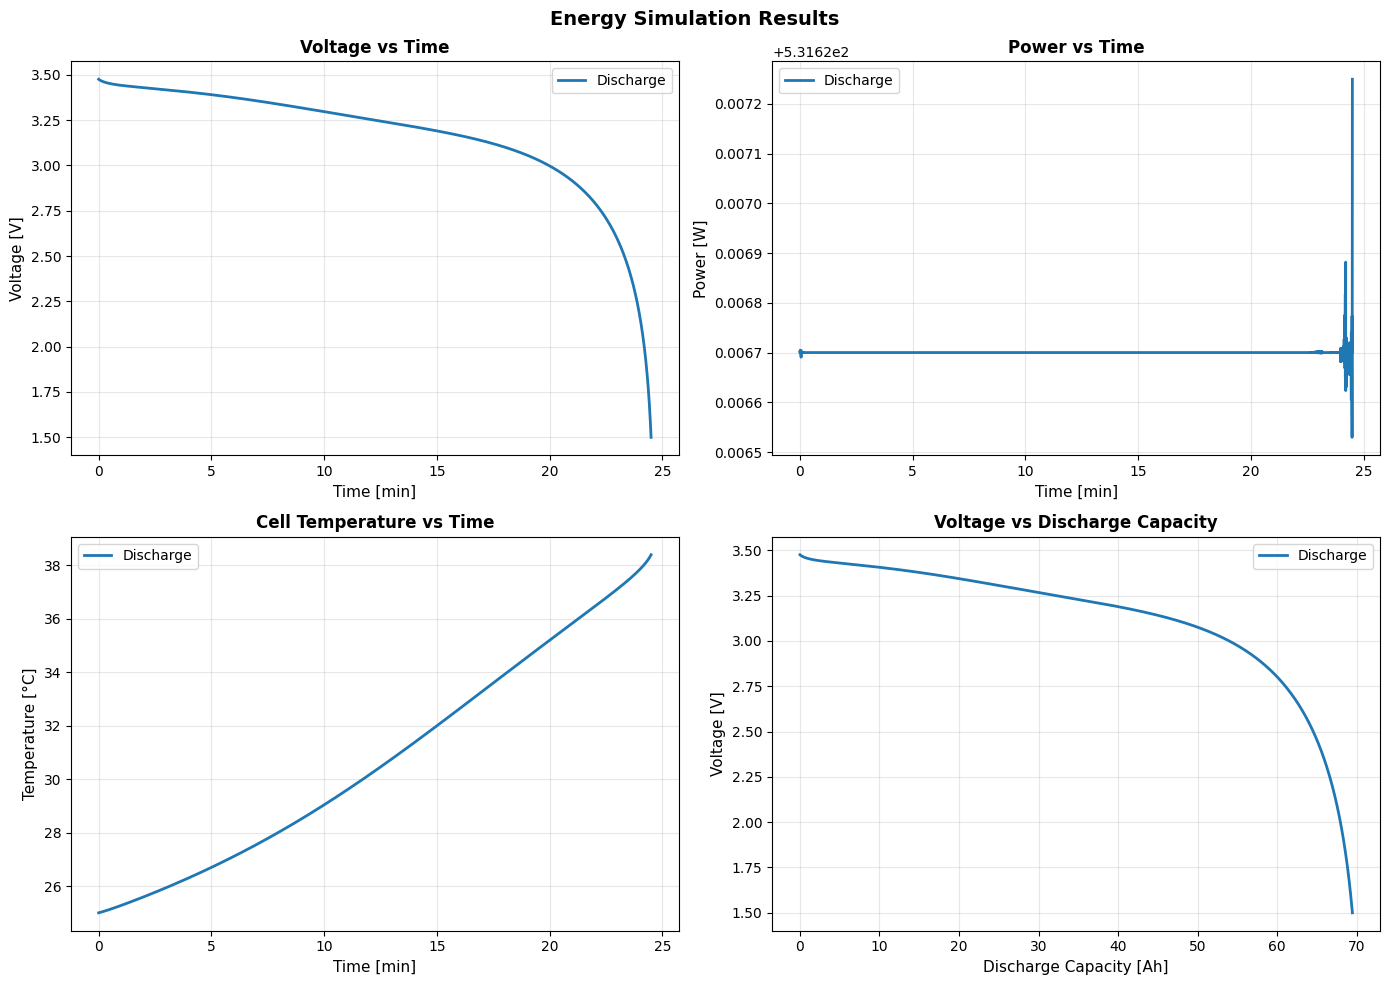


✓ Plots generated successfully!


In [5]:
if energy_data is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    if isinstance(energy_data.get('results'), list):
        # Multiple results - plot each one
        results_to_plot = energy_data['results']
    else:
        # Single result - wrap in list for uniform handling
        results_to_plot = [energy_data]
    
    # Plot 1: Voltage vs Time
    ax1 = axes[0, 0]
    for i, r in enumerate(results_to_plot):
        if isinstance(energy_data.get('results'), list):
            label = f"Simulation {i+1}"
        else:
            label = energy_data.get('label', 'Discharge')
        time_min = (r['time_s'] - r['time_s'][0]) / 60
        ax1.plot(time_min, r['voltage_V'], linewidth=2, label=label)
    ax1.set_xlabel('Time [min]', fontsize=11)
    ax1.set_ylabel('Voltage [V]', fontsize=11)
    ax1.set_title('Voltage vs Time', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Plot 2: Power vs Time
    ax2 = axes[0, 1]
    for i, r in enumerate(results_to_plot):
        if isinstance(energy_data.get('results'), list):
            label = f"Simulation {i+1}"
        else:
            label = energy_data.get('label', 'Discharge')
        time_min = (r['time_s'] - r['time_s'][0]) / 60
        power_W = r.get('power_W', np.zeros_like(r['time_s']))
        ax2.plot(time_min, power_W, linewidth=2, label=label)
    ax2.set_xlabel('Time [min]', fontsize=11)
    ax2.set_ylabel('Power [W]', fontsize=11)
    ax2.set_title('Power vs Time', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Plot 3: Temperature vs Time
    ax3 = axes[1, 0]
    for i, r in enumerate(results_to_plot):
        if isinstance(energy_data.get('results'), list):
            label = f"Simulation {i+1}"
        else:
            label = energy_data.get('label', 'Discharge')
        time_min = (r['time_s'] - r['time_s'][0]) / 60
        temp_K = r.get('temperature_K', np.full_like(r['time_s'], 298.15))
        temp_C = temp_K - 273.15
        ax3.plot(time_min, temp_C, linewidth=2, label=label)
    ax3.set_xlabel('Time [min]', fontsize=11)
    ax3.set_ylabel('Temperature [°C]', fontsize=11)
    ax3.set_title('Cell Temperature vs Time', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # Plot 4: Voltage vs Capacity
    ax4 = axes[1, 1]
    for i, r in enumerate(results_to_plot):
        if isinstance(energy_data.get('results'), list):
            label = f"Simulation {i+1}"
        else:
            label = energy_data.get('label', 'Discharge')
        capacity_Ah = r.get('capacity_Ah', np.zeros_like(r['time_s']))
        discharged_capacity = capacity_Ah - capacity_Ah[0]
        ax4.plot(discharged_capacity, r['voltage_V'], linewidth=2, label=label)
    ax4.set_xlabel('Discharge Capacity [Ah]', fontsize=11)
    ax4.set_ylabel('Voltage [V]', fontsize=11)
    ax4.set_title('Voltage vs Discharge Capacity', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.legend()

    plt.suptitle('Energy Simulation Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Plots generated successfully!")
else:
    print("\n✗ No data available for visualization. Please run the simulation first.")
